##### Section 1: Import Libraries & Load Data

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)

In [3]:
df=pd.read_csv('../data/raw/EasyVisa.csv')

##### Section 2: Basic Data Inspection

In [4]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [5]:
df.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91,Year,Y,Certified


In [6]:
df.shape

(25480, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [8]:
df.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


In [9]:
df.describe(include='object')

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,region_of_employment,unit_of_wage,full_time_position,case_status
count,25480,25480,25480,25480,25480,25480,25480,25480,25480
unique,25480,6,4,2,2,5,4,2,2
top,EZYV01,Asia,Bachelor's,Y,N,Northeast,Year,Y,Certified
freq,1,16861,10234,14802,22525,7195,22962,22773,17018


In [10]:
# drop case_id
df.nunique().sort_values(ascending=False)

case_id                  25480
prevailing_wage          25454
no_of_employees           7105
yr_of_estab                199
continent                    6
region_of_employment         5
education_of_employee        4
unit_of_wage                 4
has_job_experience           2
requires_job_training        2
full_time_position           2
case_status                  2
dtype: int64

##### Section 3: Data Quality Check

In [11]:
missing=df.isnull().sum()

In [12]:
missing

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64

In [13]:
(missing/df.shape[0])*100

case_id                  0.0
continent                0.0
education_of_employee    0.0
has_job_experience       0.0
requires_job_training    0.0
no_of_employees          0.0
yr_of_estab              0.0
region_of_employment     0.0
prevailing_wage          0.0
unit_of_wage             0.0
full_time_position       0.0
case_status              0.0
dtype: float64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
for col in df.select_dtypes(include='number').columns:
    negative_count=(df[col]<0).sum()
    zero_count=(df[col]==0).sum()
    min_value=df[col].min()
    max_value=df[col].max()
    
    print(f"Column: {col}")
    print(f"Negative Count : {negative_count}")
    print(f"Zero Count : {zero_count}")
    print(f"Min Value : {min_value}")
    print(f"Max Value : {max_value}")
    print("-" * 30)

Column: no_of_employees
Negative Count : 33
Zero Count : 0
Min Value : -26
Max Value : 602069
------------------------------
Column: yr_of_estab
Negative Count : 0
Zero Count : 0
Min Value : 1800
Max Value : 2016
------------------------------
Column: prevailing_wage
Negative Count : 0
Zero Count : 0
Min Value : 2.1367
Max Value : 319210.27
------------------------------


In [16]:
#Identify & Separate Column Types
categorical_features=df.select_dtypes(include='object').columns
numerical_features=df.select_dtypes(include='number').columns

In [17]:
categorical_features=list(categorical_features)
numerical_features=list(numerical_features)

In [18]:
categorical_features

['case_id',
 'continent',
 'education_of_employee',
 'has_job_experience',
 'requires_job_training',
 'region_of_employment',
 'unit_of_wage',
 'full_time_position',
 'case_status']

In [19]:
numerical_features

['no_of_employees', 'yr_of_estab', 'prevailing_wage']

In [20]:
discrete_features=[col for col in numerical_features if df[col].nunique() <=25]
continuous_features=[col for col in numerical_features if df[col].nunique() >25]

In [21]:
discrete_features

[]

In [22]:
continuous_features

['no_of_employees', 'yr_of_estab', 'prevailing_wage']


##### Section 4: Target Variable Analysis

In [23]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [24]:
TARGET_COL='case_status'
PROBLEM_TYPE='classification'

In [25]:
df[TARGET_COL].value_counts()

case_status
Certified    17018
Denied        8462
Name: count, dtype: int64

In [26]:
df[TARGET_COL].value_counts(normalize=True)*100

case_status
Certified    66.789639
Denied       33.210361
Name: proportion, dtype: float64

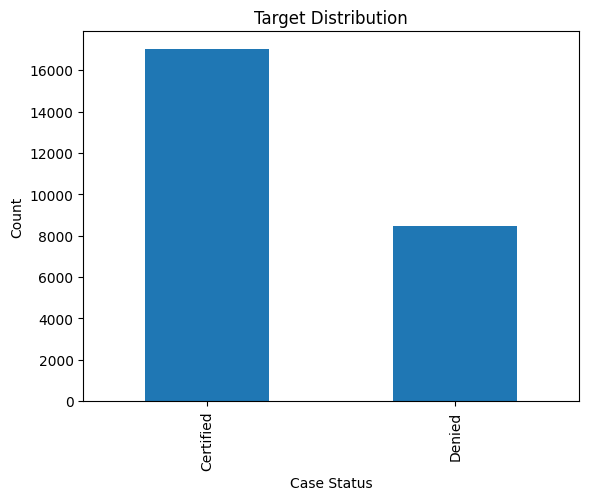

In [27]:
# Target Distribution
df[TARGET_COL].value_counts().plot(kind='bar')
plt.title('Target Distribution')
plt.xlabel('Case Status') 
plt.ylabel('Count')
plt.show()

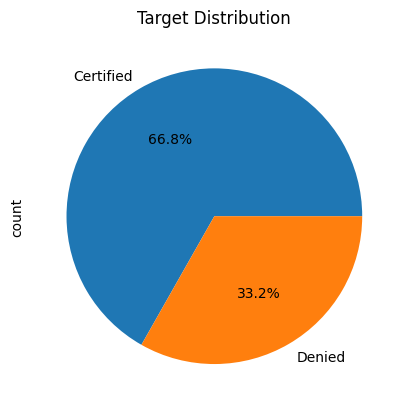

In [28]:
df[TARGET_COL].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Target Distribution')
plt.show()


##### Section 5: Univariate Analysis

In [29]:
num_cols=[col for col in numerical_features if col!=TARGET_COL]

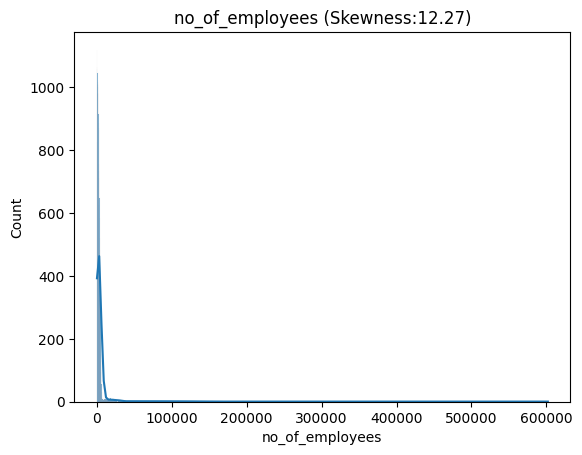

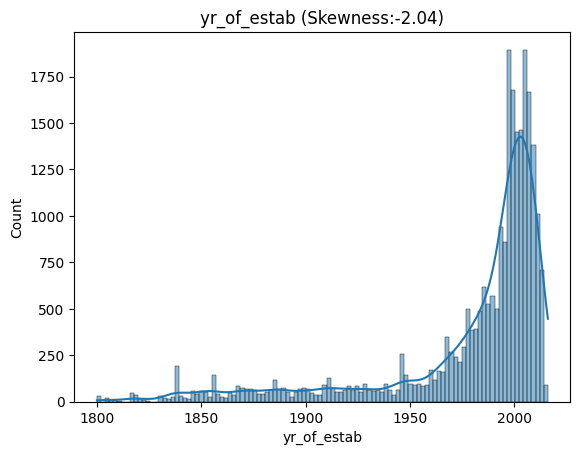

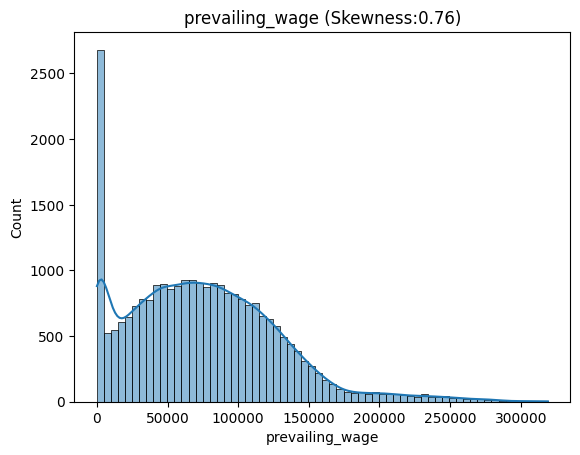

In [30]:
# Rule of thumb for skewness:
# - Skewness > 1 or < -1: Highly skewed
# - Skewness between 0.5 and 1 or -0.5 and -1: Moderately skewed
# - Skewness between -0.5 and 0.5: Approximately symmetric

for col in num_cols:
    skewness=df[col].skew()
    
    sns.histplot(df[col],kde=True)
    plt.title(f'{col} (Skewness:{skewness:.2f})')
    plt.show()

In [31]:
cat_cols=[col for col in categorical_features if col!=TARGET_COL and col!='case_id']

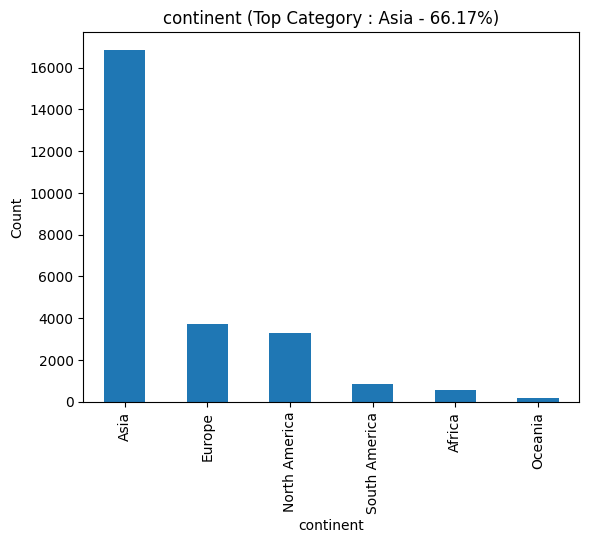

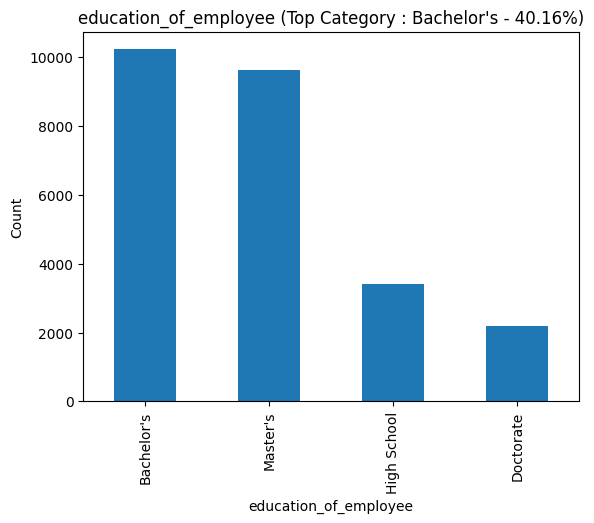

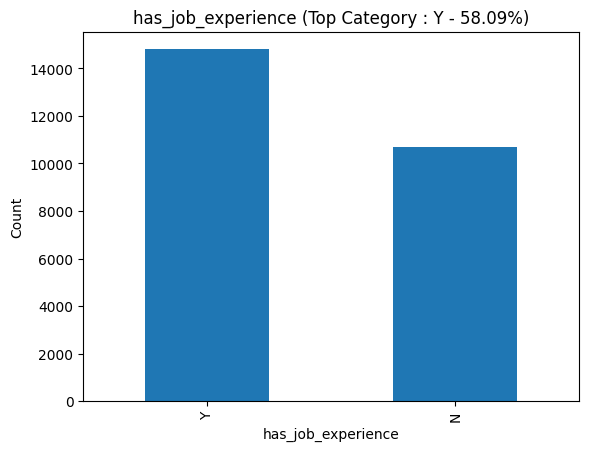

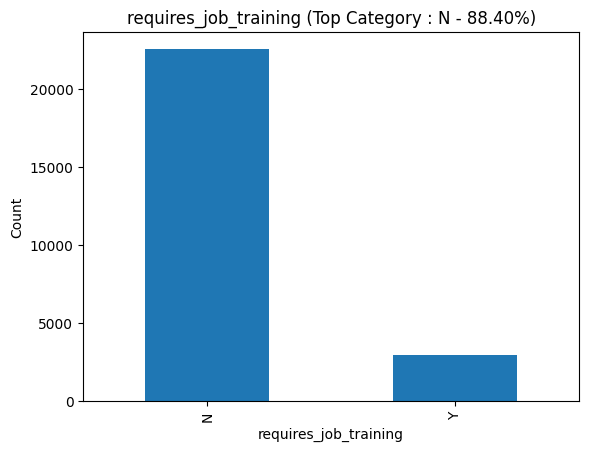

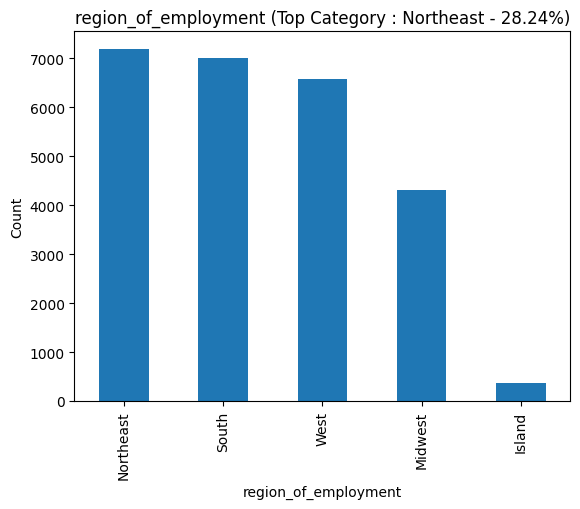

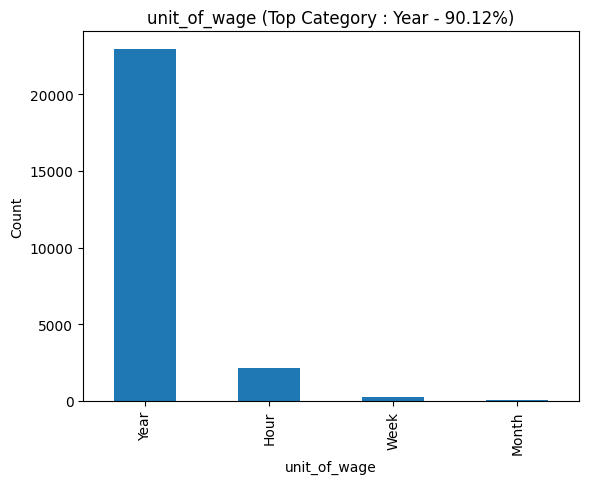

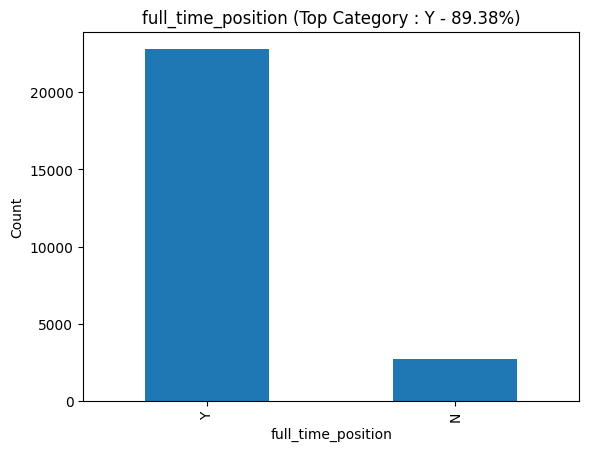

In [32]:
for col in cat_cols:
    val_counts=df[col].value_counts()
    top_pct=(val_counts[0]/df.shape[0])*100
    
    df[col].value_counts().plot(kind='bar')
    plt.title(f'{col} (Top Category : {val_counts.index[0]} - {top_pct:.2f}%)')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

##### Section 6: Outlier Detection

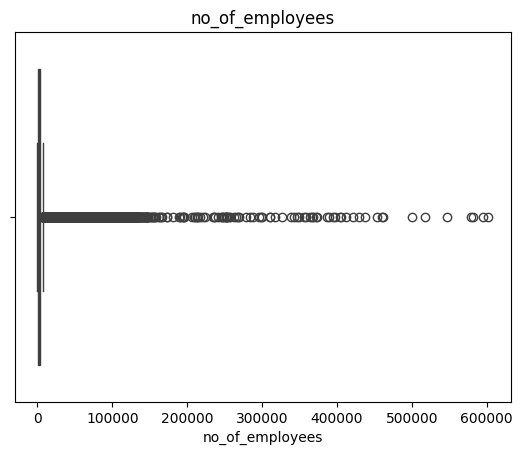

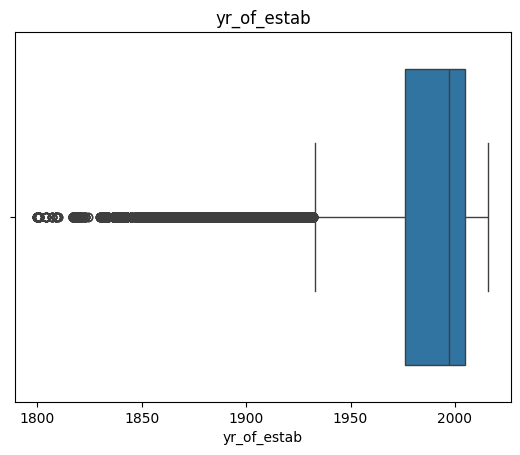

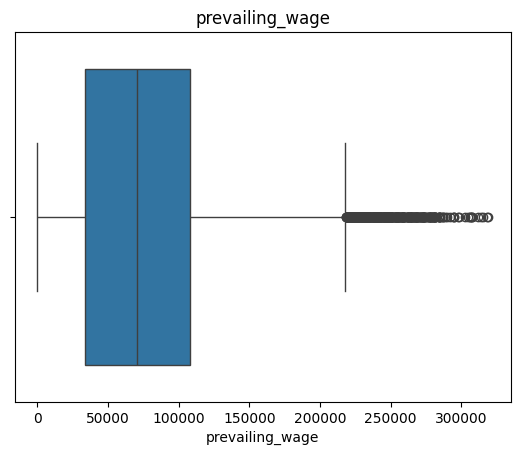

In [33]:
for col in continuous_features:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [34]:
outlier_list = []

for col in continuous_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_pct = (outlier_count / len(df)) * 100

    action = "Cap" if outlier_pct <= 5 else "Investigate"
    outlier_list.append([col, round(outlier_pct, 2), action])

In [35]:
outlier_list

[['no_of_employees', np.float64(6.11), 'Investigate'],
 ['yr_of_estab', np.float64(12.79), 'Investigate'],
 ['prevailing_wage', np.float64(1.68), 'Cap']]

##### Section 7: Bivariate & Multivariate Analysis


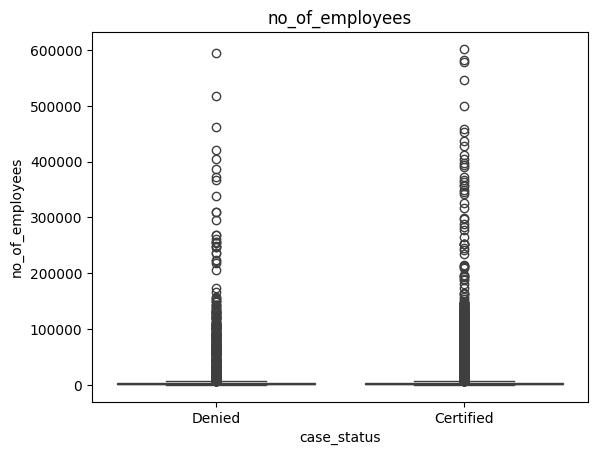

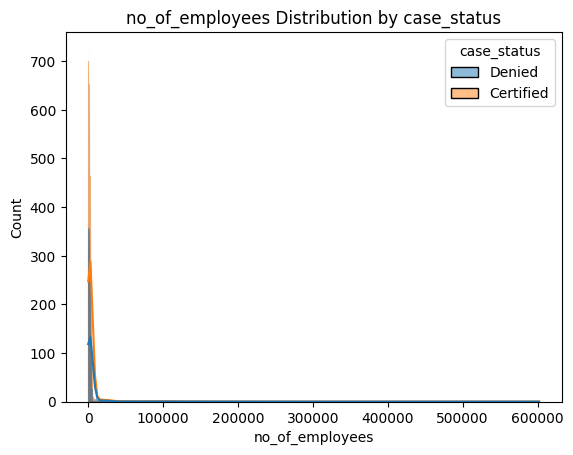

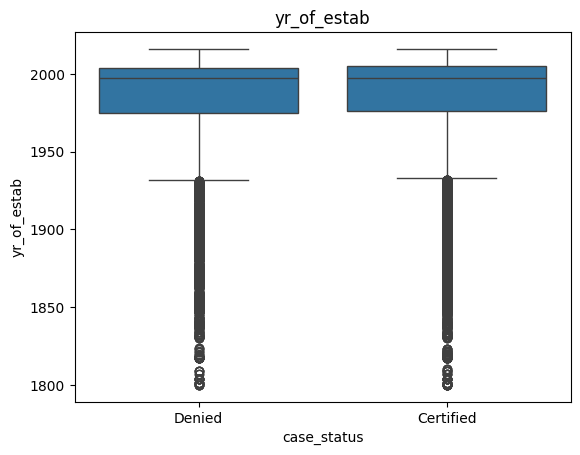

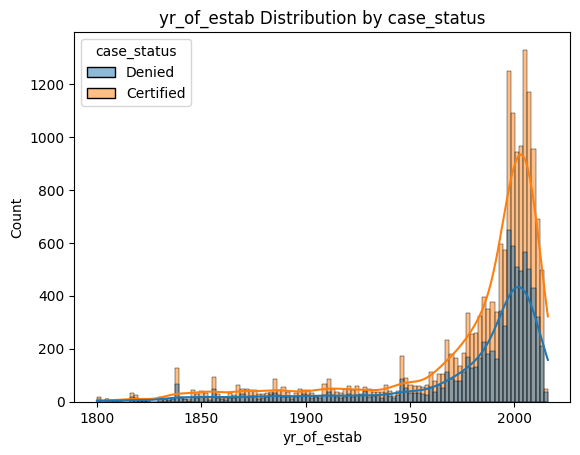

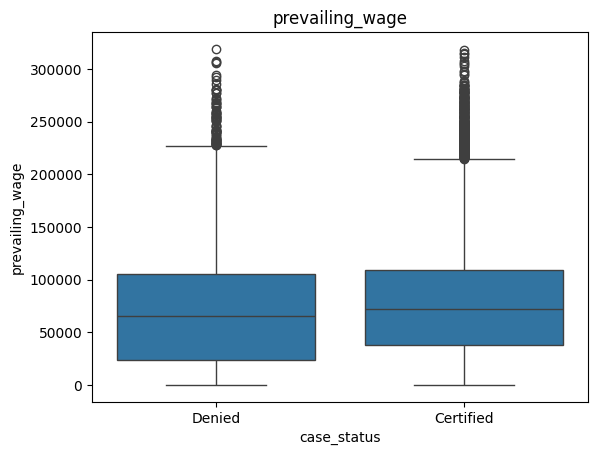

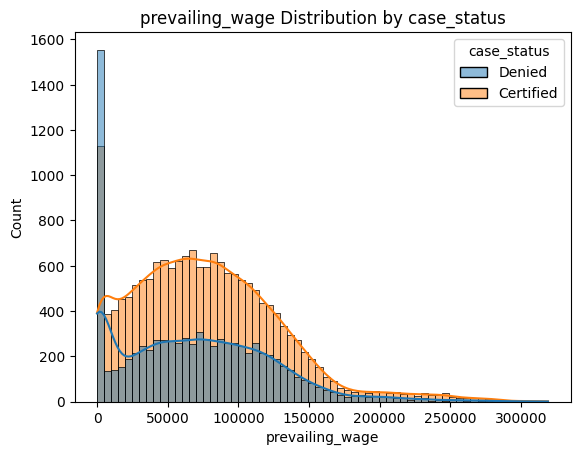

In [36]:
for col in continuous_features:
    sns.boxplot(x=TARGET_COL, y=col, data=df)
    plt.title(col)
    plt.show()
    
    sns.histplot(data=df, x=col, hue=TARGET_COL, kde=True)
    plt.title(f'{col} Distribution by {TARGET_COL}')
    plt.show()

In [37]:
corr=df.corr(numeric_only=True)

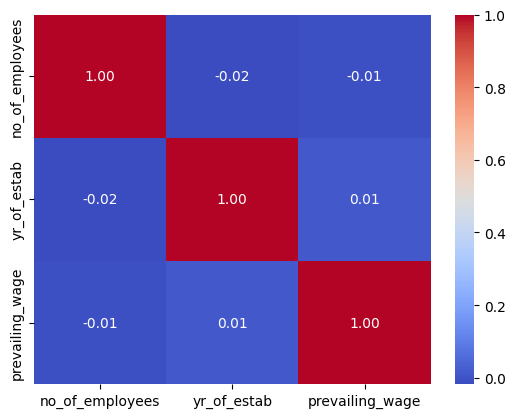

In [38]:
sns.heatmap(corr,annot=True,fmt='.2f',cmap='coolwarm')
plt.show()

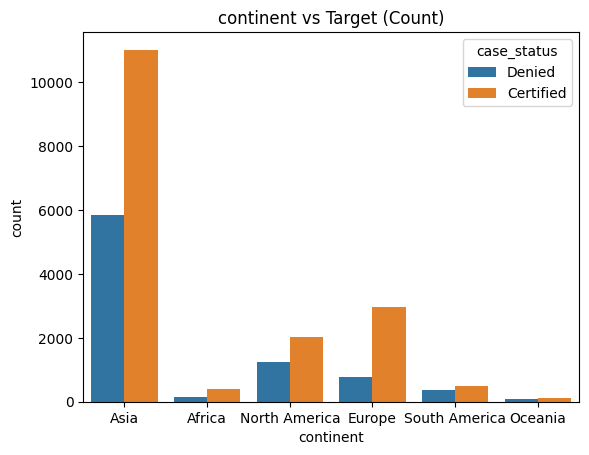

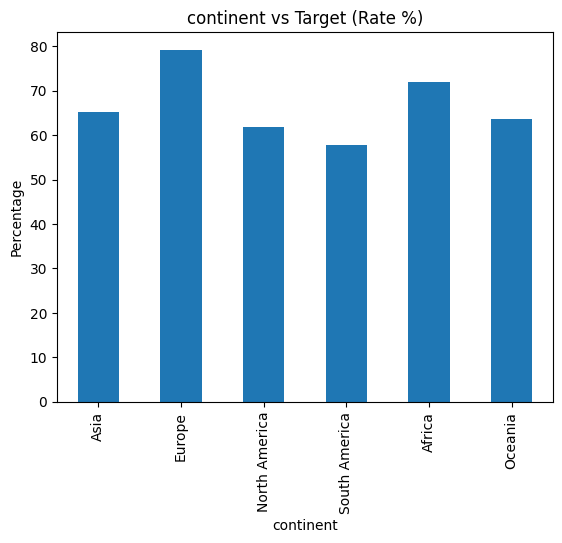

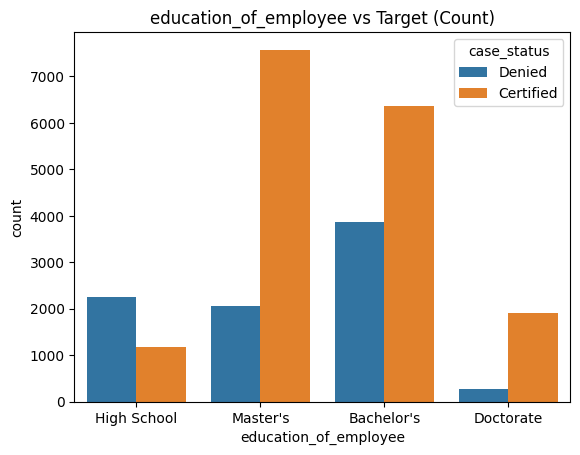

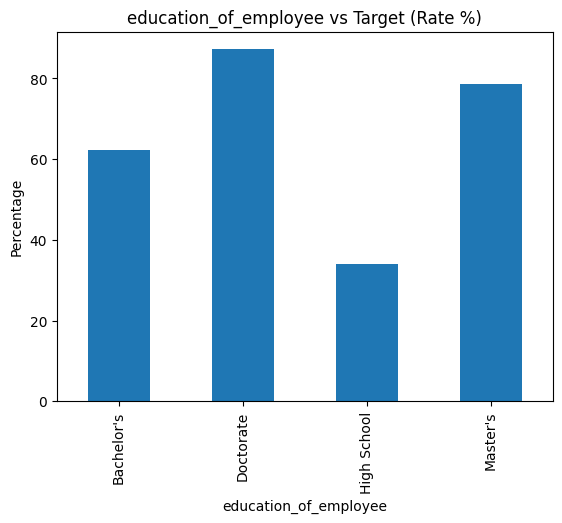

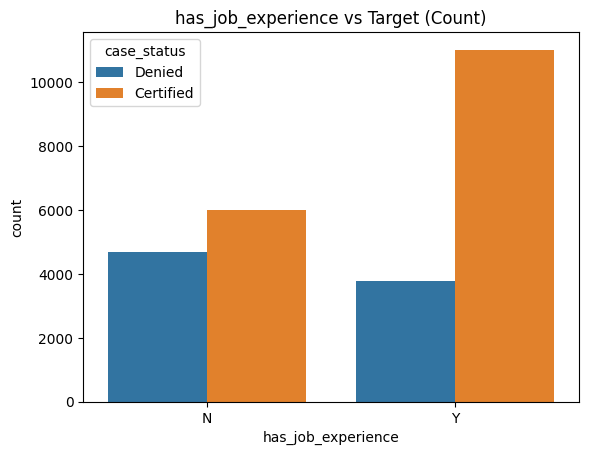

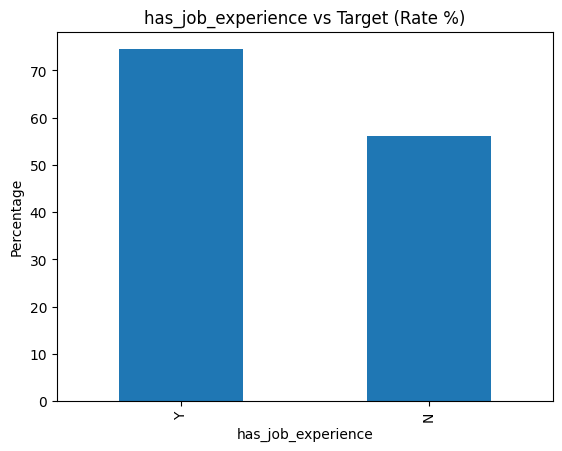

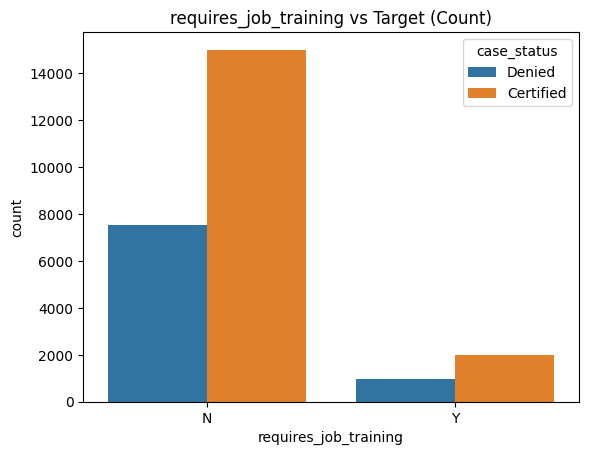

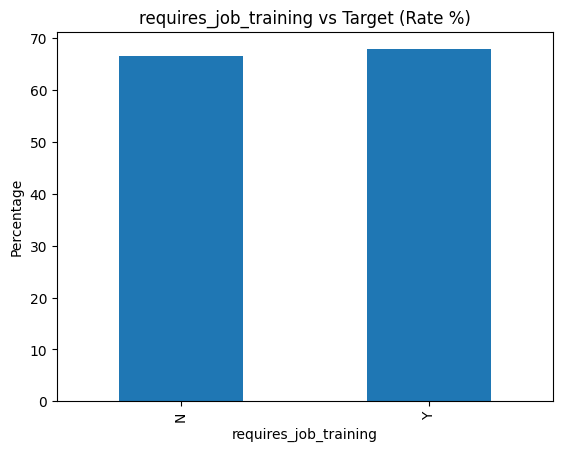

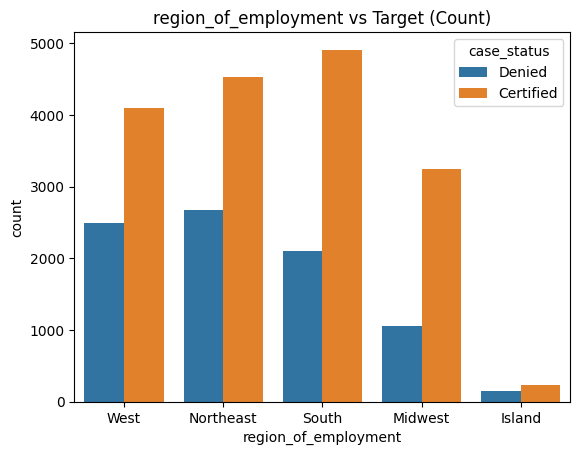

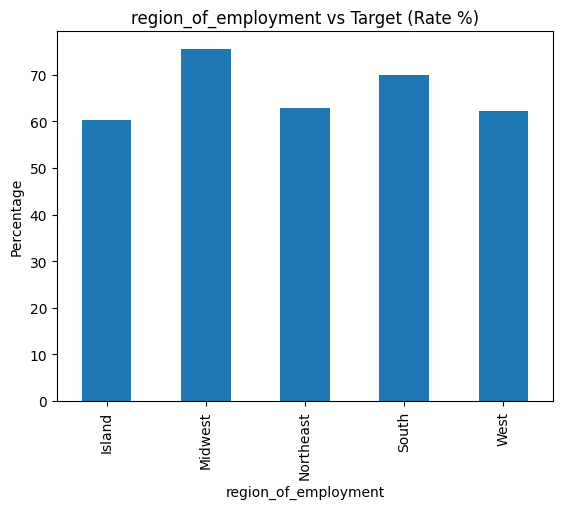

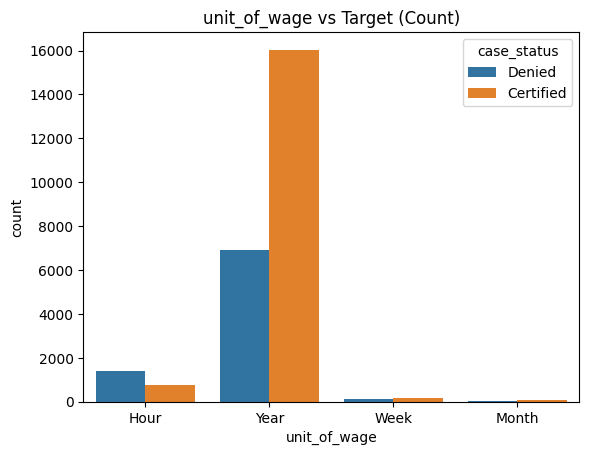

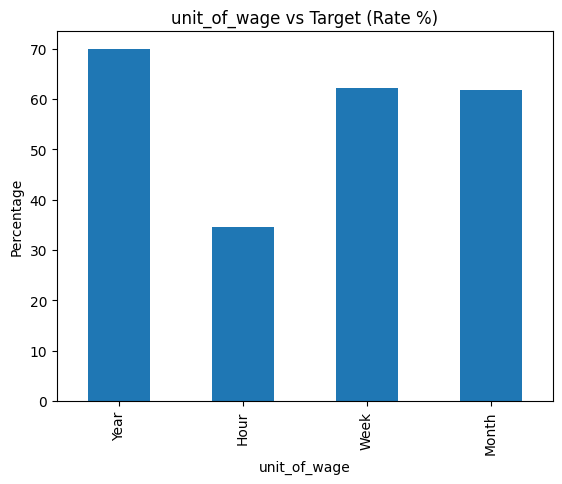

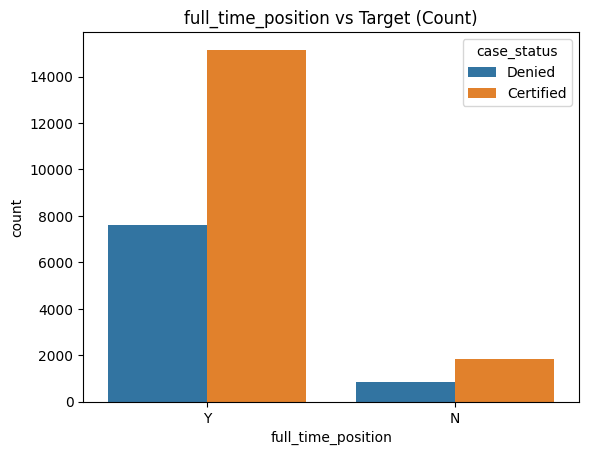

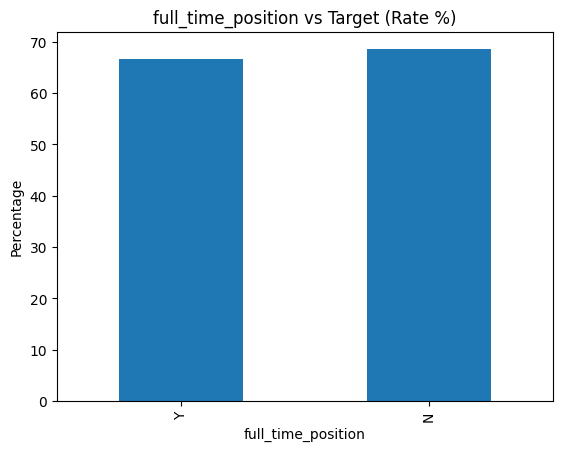

In [39]:
target_positive = df[TARGET_COL].value_counts().index[0]

for col in cat_cols:
    sns.countplot(x=col, hue=TARGET_COL, data=df)
    plt.title(f"{col} vs Target (Count)")
    plt.show()
    
    # Rate (%)
    rate = (df[df[TARGET_COL] == target_positive][col].value_counts() /
            df[col].value_counts()) * 100
    
    rate.plot(kind='bar')
    plt.title(f"{col} vs Target (Rate %)")
    plt.ylabel("Percentage")
    plt.show()

##### Chi-sqaure Test

In [41]:
for col in cat_cols:
    table=pd.crosstab(df[col],df[TARGET_COL])
    _, p, _, _ = chi2_contingency(table)
    
    if p < 0.05:
        result="Keep"
    else:
        result="Drop"
        
    print(f"Column: {col}, p-value: {p:.4f}, Result: {result}")

Column: continent, p-value: 0.0000, Result: Keep
Column: education_of_employee, p-value: 0.0000, Result: Keep
Column: has_job_experience, p-value: 0.0000, Result: Keep
Column: requires_job_training, p-value: 0.1856, Result: Drop
Column: region_of_employment, p-value: 0.0000, Result: Keep
Column: unit_of_wage, p-value: 0.0000, Result: Keep
Column: full_time_position, p-value: 0.0447, Result: Keep
